In [1]:
format short g

In [2]:
pkg install "https://github.com/gnu-octave/statistics-resampling/archive/refs/heads/master.zip"

The statistics-resampling package was installed into the directory:
/home/jovyan/.local/share/octave/api-v58/packages/statistics-resampling-5.6.1-dev
License and copyright information can be found at:
https://github.com/gnu-octave/statistics-resampling/blob/master/COPYING


In [4]:
pkg load statistics-resampling

In [5]:
[~, genotype] = xlsread ('../data/abeta-cleaned_ver1_coded.xlsx', 'Abeta', 'E2:E199');
[~, condition] = xlsread ('../data/abeta-cleaned_ver1_coded.xlsx', 'Abeta', 'F2:F199');

% for cell clusters am I averaging from the same cell into one data point
% need to load animal information once it is available

outcomes = xlsread ('../data/abeta-cleaned_ver1_coded.xlsx', 'Abeta', 'G2:S199');

disp (size(genotype))
disp (size(condition))
disp (size(outcomes))

          198            1
          198            1
          198           13


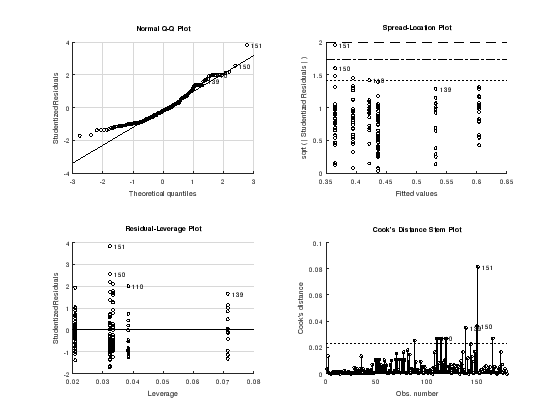

In [6]:
for i = 1: size(outcomes, 2)
    MAT_T = bootlm (outcomes(:,i), {genotype, condition}, 'model', 'full', 'display', 'on', ...
            'contrasts', 'treatment', 'nboot', 0);
    print(sprintf('../output/NC_ver1/outcome%d.png', i), 'dpng', '-r300')
end
